In [32]:
from tkinter import Tk, filedialog
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Masquer la fenêtre principale Tkinter
root = Tk()
root.withdraw()

# Forcer la fenêtre à être au premier plan
root.attributes('-topmost', True)
root.update()

# Ouvrir la fenêtre de sélection
fichier = filedialog.askopenfilename(
    title="Choisissez le fichier à analyser",
    filetypes=[("Fichiers CSV", "*.csv"), ("Fichiers Excel", "*.xlsx *.xls"), ("Tous les fichiers", "*.*")]
)

# Lecture du fichier sélectionné avec pandas
df = pd.read_csv(fichier)

C:\Users\Amine Mamdouh\AppData\Local\Temp\ipykernel_9152\470342063.py:21: DtypeWarning: Columns (77) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(fichier)


## CONDITIONS MÉTÉO & ENVIRONNEMENT

## Conditions  géographiques

In [33]:
import pandas as pd
import numpy as np

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

import matplotlib.pyplot as plt

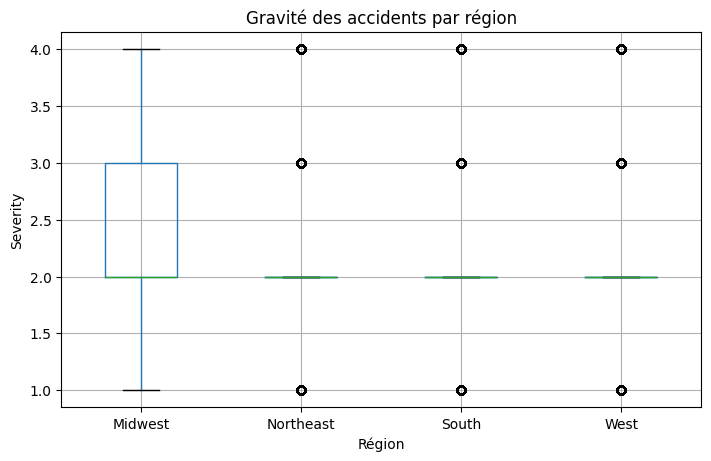

In [34]:
df.dropna(subset=['Severity', 'Region']).boxplot(column='Severity', by='Region', figsize=(8,5))
plt.title('Gravité des accidents par région')
plt.suptitle('')
plt.xlabel('Région')
plt.ylabel('Severity')
plt.show()


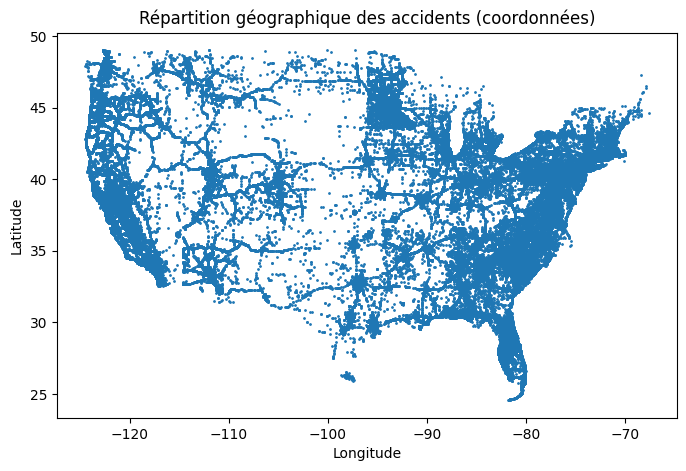

In [35]:
plt.figure(figsize=(8,5))
plt.scatter(df['Start_Lng'], df['Start_Lat'], s=1)
plt.title('Répartition géographique des accidents (coordonnées)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()


Test t de Student

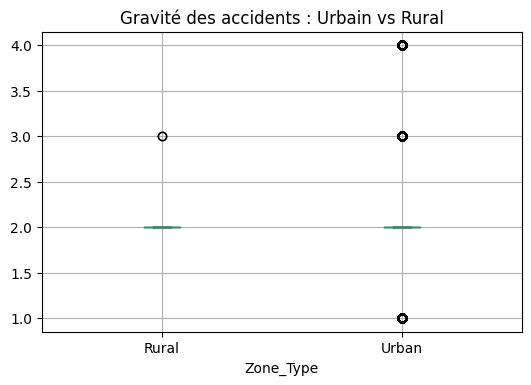

In [36]:
df.boxplot(column='Severity', by='Zone_Type', figsize=(6,4))
plt.title('Gravité des accidents : Urbain vs Rural')
plt.suptitle('')
plt.show()


Corrélation — Densité d’accidents & Gravité

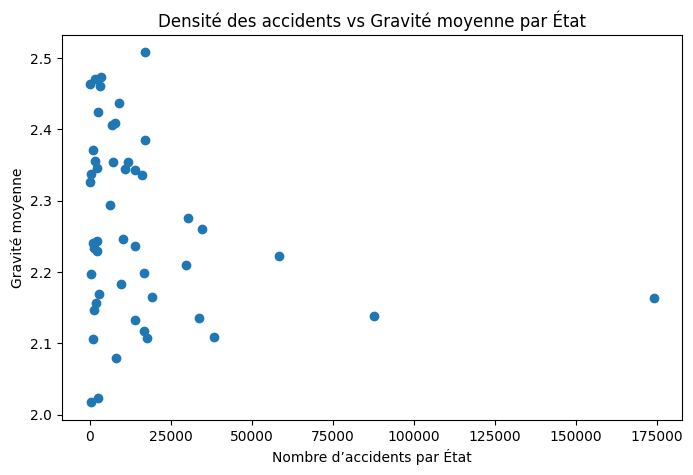

In [37]:
state_stats = df.groupby('State').agg(
    Accident_Count=('Severity', 'count'),   # ← correction ici
    Avg_Severity=('Severity', 'mean')
).reset_index()

plt.figure(figsize=(8,5))
plt.scatter(state_stats['Accident_Count'], state_stats['Avg_Severity'])
plt.xlabel('Nombre d’accidents par État')
plt.ylabel('Gravité moyenne')
plt.title('Densité des accidents vs Gravité moyenne par État')
plt.show()


Test du Chi-deux — Région vs Niveau de Risque

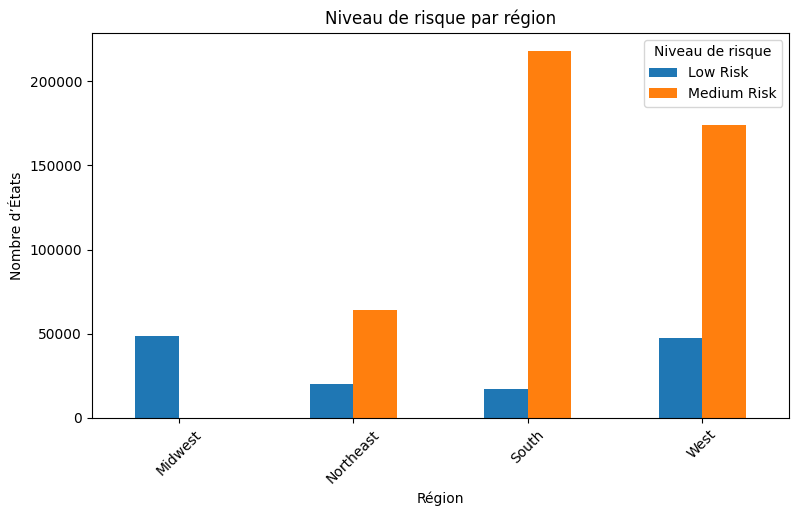

In [38]:
#tableau de contingence entre Région et Niveau de Risque de l'État
contingency = pd.crosstab(
    df['Region'],
    df['State_Risk_Level']
)
contingency.plot(kind='bar', figsize=(9,5))
plt.title('Niveau de risque par région')
plt.xlabel('Région')
plt.ylabel('Nombre d’États')
plt.xticks(rotation=45)
plt.legend(title='Niveau de risque')
plt.show()


 KPI --------------> Accident Count by State

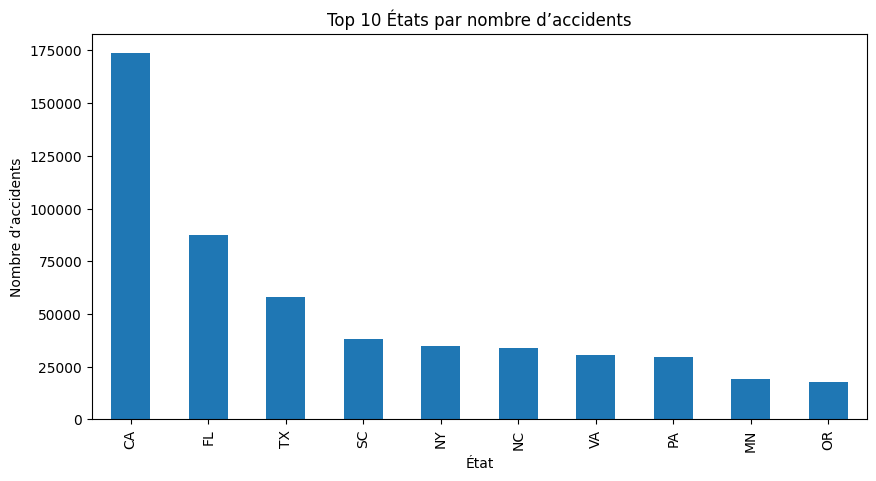

In [39]:
acc_by_state = df['State'].value_counts().head(10)

acc_by_state.plot(kind='bar', figsize=(10,5), title='Top 10 États par nombre d’accidents')
plt.xlabel('État')
plt.ylabel('Nombre d’accidents')
plt.show()


KPI------> Accident Distribution by Region

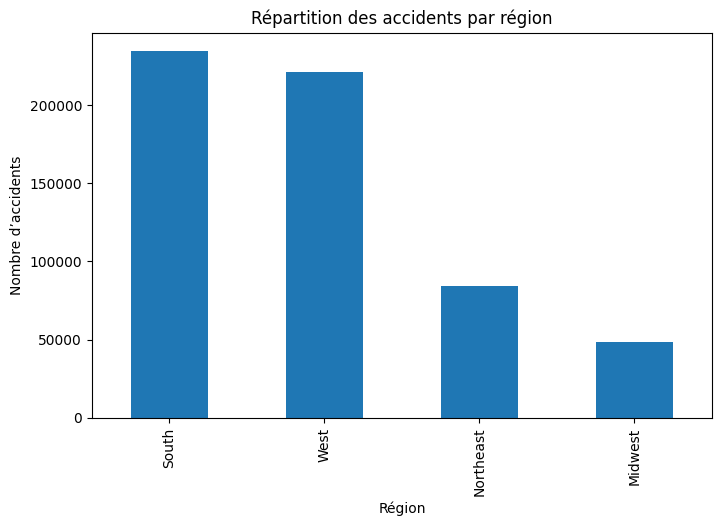

In [40]:
acc_by_region = df['Region'].value_counts()

acc_by_region.plot(kind='bar', figsize=(8,5), title='Répartition des accidents par région')
plt.xlabel('Région')
plt.ylabel('Nombre d’accidents')
plt.show()


KPI----->High Risk States Ratio

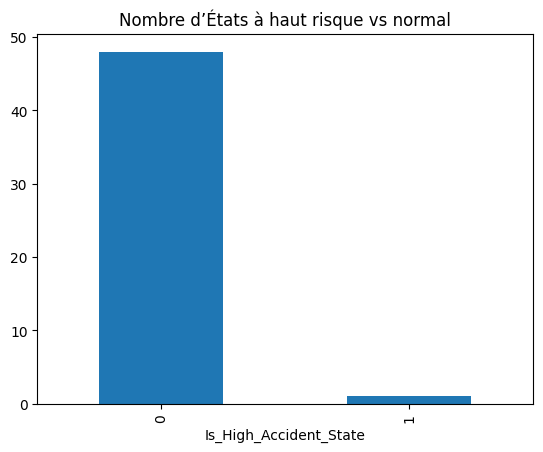

In [41]:
df[['State', 'Is_High_Accident_State']].drop_duplicates()['Is_High_Accident_State'] \
    .value_counts() \
    .plot(kind='bar', title='Nombre d’États à haut risque vs normal')
plt.show()



<Axes: title={'center': 'Répartition des accidents par région'}, ylabel='count'>

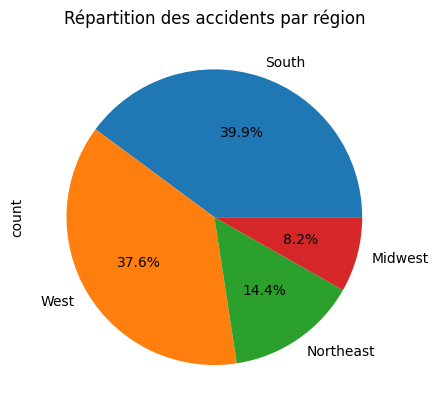

In [42]:
df['Region'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    title='Répartition des accidents par région'
)


<Axes: title={'center': 'Top 10 des villes avec le plus d’accidents'}, xlabel='City'>

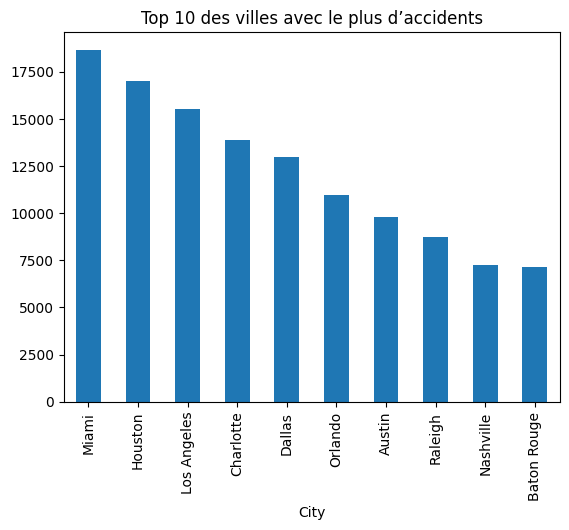

In [43]:
top_cities = df['City'].value_counts().head(10)

top_cities.plot(
    kind='bar',
    title='Top 10 des villes avec le plus d’accidents'
)